### Goals:

1. Merge 1st dataframe with the 2nd dataframe, for the software engineer jobs

In [1]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

In [2]:
# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

## Preparation 1st Dataframe

In [ ]:
# search for job that based in Indonesia
df_indo = df[df['job_country'] == 'Indonesia'].copy()

# transform month from numeric into string 
df_indo['job_posted_month'] = df_indo['job_posted_date'].dt.strftime('%B')

# create pivot
df_indo_pivot = df_indo.pivot_table(index="job_posted_month", columns='job_title_short', aggfunc='size')

# Sorting month
df_indo_pivot.reset_index(inplace=True)

# Take kolom job posted month, terus di format jadi ke angka
df_indo_pivot['month_no'] = pd.to_datetime(df_indo_pivot['job_posted_month'], format='%B').dt.month

# Sort month dari jan ke dec 
df_indo_pivot.sort_values('month_no', inplace=True)

# ngeset kolom job_posted_month jadi index 
# kalau udah di set, gabisa di run lagi, kecuali udah di reset lagi indexnya
df_indo_pivot.set_index('job_posted_month',inplace=True)

# drop kolom month_no
df_indo_pivot.drop(columns='month_no',inplace=True)

In [6]:
df_indo_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,14,9,35,117,80,8,5,10,19,14
February,9,2,25,78,44,5,4,12,5,18
March,6,5,21,90,36,2,1,13,5,14
April,5,3,20,46,28,2,1,9,8,14
May,11,9,25,79,39,3,2,8,9,4
June,11,4,22,66,32,4,1,8,9,8
July,11,3,25,58,46,9,4,8,3,20
August,12,5,32,78,46,1,3,5,5,15
September,4,7,34,83,50,6,5,10,8,9


## 2nd Dataframe

In [10]:
# pd.read_csv('https://lukeb.co/software_csv')

# karena index yang data diatas beda dengan data pertama, 
# maka kita harus ubah indexnya jadi pake job posted month

df_software_pivot = pd.read_csv('https://lukeb.co/software_csv', index_col='job_posted_month')
df_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


## Merging

In [ ]:
# choose kolom yang sama buat dijadiin patokan merge 
df_merged = df_indo_pivot.merge(df_software_pivot, on='job_posted_month')
df_merged

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,14,9,35,117,80,8,5,10,19,14,13619,9827,5108,4348
February,9,2,25,78,44,5,4,12,5,18,11456,9116,7298,4284
March,6,5,21,90,36,2,1,13,5,14,11102,8178,5814,4159
April,5,3,20,46,28,2,1,9,8,14,14037,9209,7232,4220
May,11,9,25,79,39,3,2,8,9,4,12126,8864,6718,4980
June,11,4,22,66,32,4,1,8,9,8,12003,8065,5902,4781
July,11,3,25,58,46,9,4,8,3,20,11914,8061,6839,4344
August,12,5,32,78,46,1,3,5,5,15,11571,8191,7413,4104
September,4,7,34,83,50,6,5,10,8,9,14016,8447,6139,4094


In [19]:
# search top 5 
top_5 = (
    df_merged
    .sum()
    .sort_values(ascending=False)
    .head()
    .index
    .to_list())
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer',
 'Data Engineer']

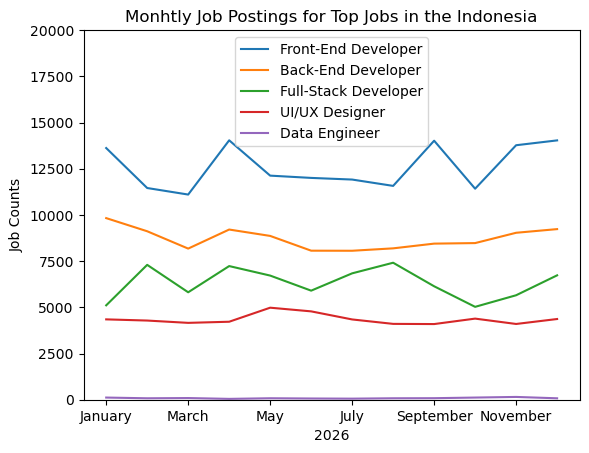

In [22]:
# Create plot 

df_merged[top_5].plot(kind='line')
plt.title('Monhtly Job Postings for Top Jobs in the Indonesia')
plt.xlabel('2026')
plt.ylabel('Job Counts')
plt.ylim(0,20000)
plt.legend()
plt.show()